In [43]:
# =========================================
# BLOCK 1 — Load Dataset & Basic Structure
# =========================================

import pandas as pd
import numpy as np

DATA_PATH = "/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_synthetic_forecasting_dataset_monthly_36m.xlsx"

df = pd.read_excel(DATA_PATH, sheet_name="FG_Demand_Long")

df["month"] = pd.to_datetime(df["month"])
df = df.sort_values(["fg_code","month"])

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nDate Range:", df["month"].min(), "→", df["month"].max())
print("Number of SKUs:", df["fg_code"].nunique())
print("Number of Months:", df["month"].nunique())

df.head()


Shape: (3708, 5)
Columns: ['month', 'fg_code', 'fg_name', 'fg_category', 'demand_units']

Date Range: 2023-02-01 00:00:00 → 2026-01-01 00:00:00
Number of SKUs: 103
Number of Months: 36


,month,fg_code,fg_name,fg_category,demand_units
0,2023-02-01,FG001,Baby Soap 50g,Soap,27456
103,2023-03-01,FG001,Baby Soap 50g,Soap,27316
206,2023-04-01,FG001,Baby Soap 50g,Soap,25194
309,2023-05-01,FG001,Baby Soap 50g,Soap,22610
412,2023-06-01,FG001,Baby Soap 50g,Soap,22763


In [44]:
# =========================================
# BLOCK 2 — Create Complete Monthly Calendar
# =========================================

all_months = pd.date_range(df["month"].min(), df["month"].max(), freq="MS")
skus = df["fg_code"].unique()

full = (
    pd.MultiIndex.from_product([skus, all_months], names=["fg_code","month"])
    .to_frame(index=False)
    .merge(df, on=["fg_code","month"], how="left")
)

missing_count = full["demand_units"].isna().sum()
print("Missing demand values before fill:", missing_count)

# Fill missing with 0 (correct for warehouse sales data)
full["demand_units"] = full["demand_units"].fillna(0)

print("Final shape:", full.shape)


Missing demand values before fill: 0
Final shape: (3708, 5)


In [45]:
# =========================================
# BLOCK 3 — Per-SKU Statistics
# =========================================

sku_stats = full.groupby("fg_code")["demand_units"].agg(
    mean="mean",
    std="std",
    min="min",
    max="max",
    total="sum"
).reset_index()

sku_stats["cv"] = sku_stats["std"] / (sku_stats["mean"] + 1e-9)
sku_stats["zero_ratio"] = full.groupby("fg_code")["demand_units"].apply(lambda x: (x==0).mean()).values

sku_stats.describe()


,mean,std,min,max,total,cv,zero_ratio
count,103.000000,103.000000,103.000000,103.000000,1.030000e+02,103.000000,103.0
mean,29995.533711,3633.188717,22656.388350,38333.087379,1.079839e+06,0.130721,0.0
std,18389.598147,2179.181271,14448.348328,23251.371796,6.620255e+05,0.040147,0.0
min,4125.333333,673.624777,2266.000000,6369.000000,1.485120e+05,0.063705,0.0
25%,16935.861111,1839.790447,12699.500000,20256.500000,6.096910e+05,0.108850,0.0
50%,26967.250000,3223.655986,21003.000000,35651.000000,9.708210e+05,0.130738,0.0
75%,40335.847222,4829.836299,29571.000000,50304.500000,1.452090e+06,0.144489,0.0
max,80146.861111,11187.166884,60873.000000,108530.000000,2.885287e+06,0.294333,0.0


In [46]:
# =========================================
# BLOCK 4 — SKU Segmentation
# =========================================

def segment(row):
    if row["zero_ratio"] > 0.3:
        return "Intermittent"
    elif row["cv"] > 1.0:
        return "Erratic"
    elif row["cv"] < 0.5:
        return "Smooth"
    else:
        return "Moderate"

sku_stats["segment"] = sku_stats.apply(segment, axis=1)

sku_stats["segment"].value_counts()


segment
Smooth    103
Name: count, dtype: int64

Global skewness: 0.7754458894979624


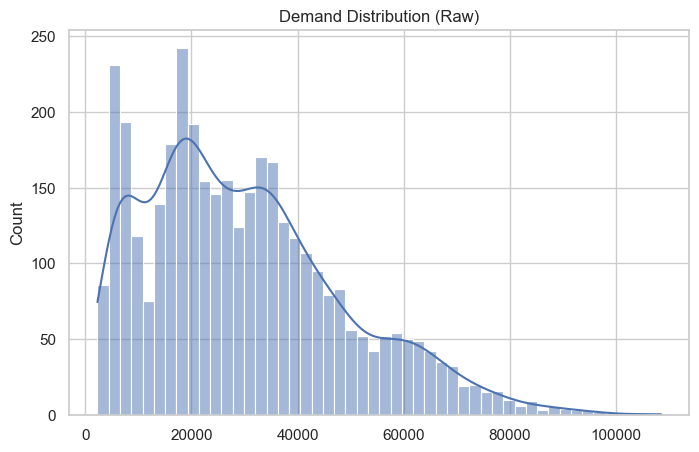

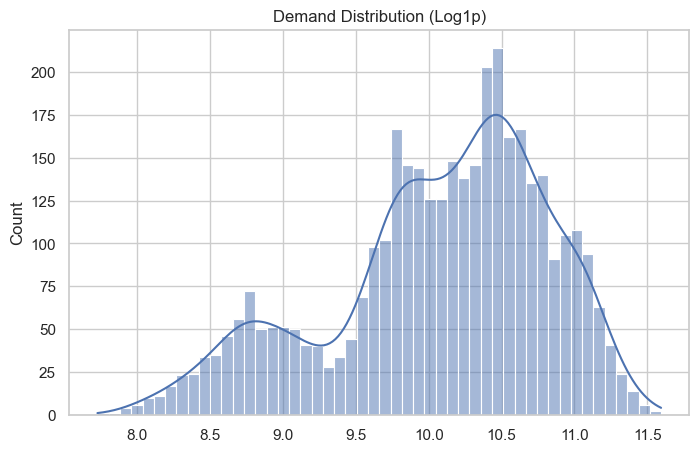

In [47]:
# =========================================
# BLOCK 5 — Skewness & Distribution
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

all_values = full["demand_units"].values

print("Global skewness:", skew(all_values))

plt.figure(figsize=(8,5))
sns.histplot(all_values, bins=50, kde=True)
plt.title("Demand Distribution (Raw)")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(all_values), bins=50, kde=True)
plt.title("Demand Distribution (Log1p)")
plt.show()


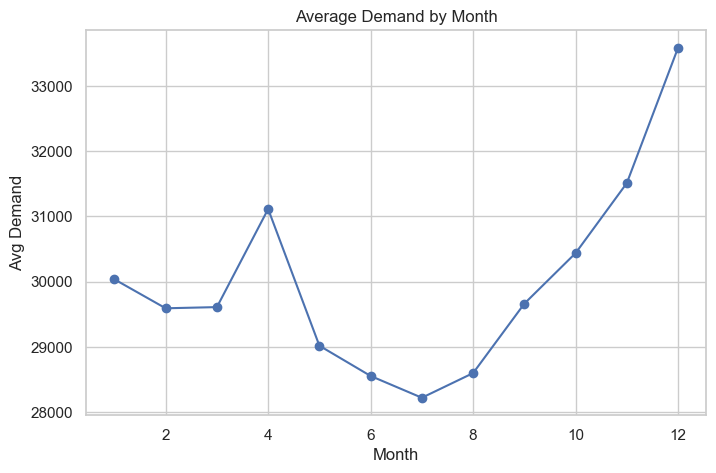

In [48]:
# =========================================
# BLOCK 6 — Seasonality Check
# =========================================

full["month_num"] = full["month"].dt.month

monthly_avg = full.groupby("month_num")["demand_units"].mean()

plt.figure(figsize=(8,5))
monthly_avg.plot(marker="o")
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Avg Demand")
plt.show()


<Figure size 800x500 with 0 Axes>

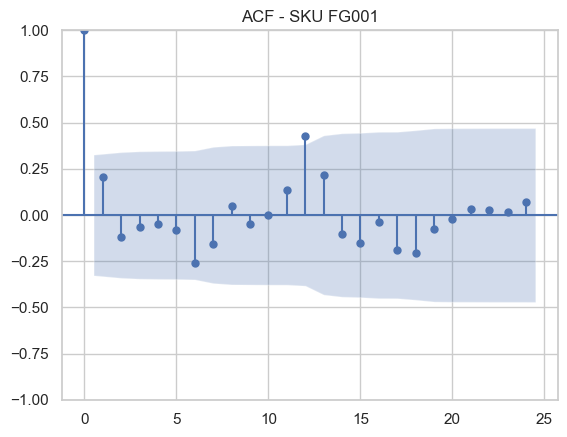

In [49]:
# =========================================
# BLOCK 7 — Autocorrelation (Sample SKU)
# =========================================

from statsmodels.graphics.tsaplots import plot_acf

sample_sku = full["fg_code"].unique()[0]
series = full[full["fg_code"] == sample_sku]["demand_units"]

plt.figure(figsize=(8,5))
plot_acf(series, lags=24)
plt.title(f"ACF - SKU {sample_sku}")
plt.show()


In [50]:
# =========================================
# BLOCK 8 — Outlier Detection
# =========================================

def detect_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = max(0, q1 - 1.5 * iqr)
    return ((group > upper) | (group < lower)).sum()

outlier_counts = full.groupby("fg_code")["demand_units"].apply(detect_outliers)

print("Total SKUs with outliers:", (outlier_counts > 0).sum())


Total SKUs with outliers: 38


In [51]:
# =========================================
# BLOCK 9 — Data Quality Checks
# =========================================

print("Negative values:", (full["demand_units"] < 0).sum())
print("Null values:", full.isnull().sum().sum())

# Check if any SKU has completely zero demand
zero_skus = sku_stats[sku_stats["total"] == 0]["fg_code"]
print("SKUs with zero total demand:", len(zero_skus))


Negative values: 0
Null values: 0
SKUs with zero total demand: 0


In [52]:
# =========================================
# BLOCK 10 — Final Clean Dataset
# =========================================

# Remove fully zero SKUs
clean_skus = sku_stats[sku_stats["total"] > 0]["fg_code"]

clean_df = full[full["fg_code"].isin(clean_skus)].copy()

print("Final modeling shape:", clean_df.shape)


Final modeling shape: (3708, 6)


## WMS Forecasting Deep-Dive (Added)

This section expands EDA for warehouse demand forecasting with:
- panel integrity and hierarchy diagnostics,
- intermittent-demand diagnostics (ADI/CV2),
- robust outlier detection and cleaned target generation,
- model-readiness statistics for ETS, tree models, and global deep models.


In [53]:
# =========================================
# BLOCK 11 — WMS Forecast Audit Setup
# =========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import median_abs_deviation
from statsmodels.tsa.seasonal import STL

sns.set_theme(style="whitegrid")

# Rebuild clean_df if the previous cells were not executed in this session.
required_cols = {"month", "fg_code", "fg_name", "fg_category", "demand_units"}
if "clean_df" not in globals() or not required_cols.issubset(set(clean_df.columns)):
    base_df = pd.read_excel(DATA_PATH, sheet_name="FG_Demand_Long")
    base_df["month"] = pd.to_datetime(base_df["month"])
    base_df = base_df.sort_values(["fg_code", "month"])

    all_months = pd.date_range(base_df["month"].min(), base_df["month"].max(), freq="MS")
    skus = base_df["fg_code"].unique()

    full_df = (
        pd.MultiIndex.from_product([skus, all_months], names=["fg_code", "month"])
        .to_frame(index=False)
        .merge(base_df, on=["fg_code", "month"], how="left")
    )
    full_df["demand_units"] = full_df["demand_units"].fillna(0)

    sku_totals = full_df.groupby("fg_code")["demand_units"].sum()
    clean_skus = sku_totals[sku_totals > 0].index
    clean_df = full_df[full_df["fg_code"].isin(clean_skus)].copy()

clean_df = clean_df.sort_values(["fg_code", "month"]).reset_index(drop=True)
print("Ready dataset:", clean_df.shape)


Ready dataset: (3708, 6)


In [54]:
# =========================================
# BLOCK 12 — Panel, Hierarchy, and Data-Quality Audit
# =========================================

# Primary key uniqueness check.
pk_dupes = clean_df.duplicated(subset=["fg_code", "month"]).sum()

# Balanced panel checks.
obs_per_sku = clean_df.groupby("fg_code").size()
balanced_panel = obs_per_sku.nunique() == 1

# WMS hierarchy checks.
name_per_sku = clean_df.groupby("fg_code")["fg_name"].nunique().max()
cat_per_sku = clean_df.groupby("fg_code")["fg_category"].nunique().max()

# Category share concentration.
cat_share = (
    clean_df.groupby("fg_category")["demand_units"].sum()
    .sort_values(ascending=False)
)
cat_share = cat_share / cat_share.sum()

# Drift check: compare first half vs second half mean per SKU.
split_date = clean_df["month"].sort_values().unique()[len(clean_df["month"].unique()) // 2]
first_half = clean_df[clean_df["month"] <= split_date].groupby("fg_code")["demand_units"].mean()
second_half = clean_df[clean_df["month"] > split_date].groupby("fg_code")["demand_units"].mean()
drift_ratio = ((second_half - first_half) / (first_half.replace(0, np.nan))).replace([np.inf, -np.inf], np.nan)

print("Duplicate (fg_code, month) rows:", int(pk_dupes))
print("Balanced panel (same months per SKU):", bool(balanced_panel))
print("Observations per SKU (min/max):", int(obs_per_sku.min()), int(obs_per_sku.max()))
print("Max fg_name count per fg_code:", int(name_per_sku))
print("Max fg_category count per fg_code:", int(cat_per_sku))
print("Top-5 category demand shares:")
print((cat_share.head(5) * 100).round(2).astype(str) + "%")

print("\nSKU drift ratio summary ((2nd half - 1st half) / 1st half):")
print(drift_ratio.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3))


Duplicate (fg_code, month) rows: 0
Balanced panel (same months per SKU): True
Observations per SKU (min/max): 36 36
Max fg_name count per fg_code: 1
Max fg_category count per fg_code: 1
Top-5 category demand shares:
fg_category
Soap           25.46%
Shampoo        20.67%
Diaper         16.62%
Liquid Wash     8.91%
Sanitary        7.82%
Name: demand_units, dtype: object

SKU drift ratio summary ((2nd half - 1st half) / 1st half):
count    103.000
mean       0.065
std        0.052
min       -0.055
10%       -0.000
25%        0.030
50%        0.068
75%        0.092
90%        0.130
max        0.278
Name: demand_units, dtype: float64


Intermittency summary:
         ADI      CV2  non_zero_ratio
count  103.0  103.000           103.0
mean     1.0    0.019             1.0
std      0.0    0.014             0.0
min      1.0    0.004             1.0
25%      1.0    0.012             1.0
50%      1.0    0.017             1.0
75%      1.0    0.021             1.0
max      1.0    0.087             1.0

SBC segment counts:
sbc_segment
Smooth    103
Name: count, dtype: int64


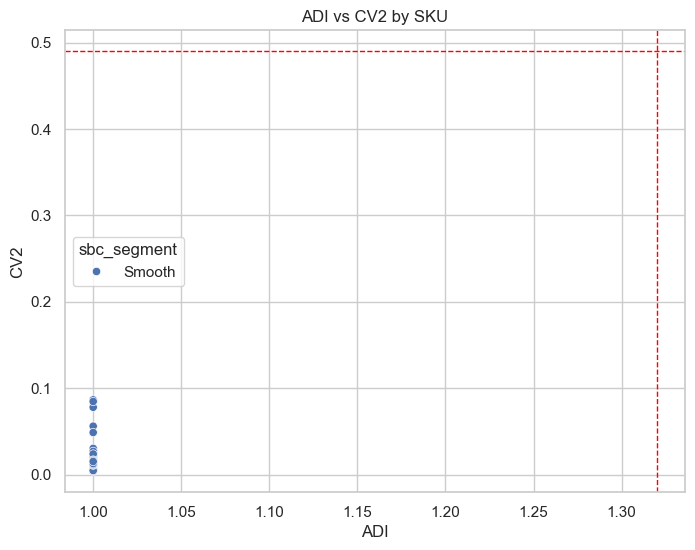

In [55]:
# =========================================
# BLOCK 13 — Intermittency Diagnostics (ADI/CV2)
# =========================================

# ADI = average interval between non-zero demands.
# CV2 = squared coefficient of variation of non-zero demand sizes.

def intermittent_metrics(group):
    y = group["demand_units"].to_numpy()
    nz_idx = np.where(y > 0)[0]

    if len(nz_idx) == 0:
        return pd.Series({"ADI": np.nan, "CV2": np.nan, "non_zero_ratio": 0.0})

    intervals = np.diff(np.r_[[-1], nz_idx])
    adi = intervals.mean()

    nz_vals = y[y > 0]
    mean_nz = nz_vals.mean()
    cv2 = ((nz_vals.std(ddof=1) / mean_nz) ** 2) if len(nz_vals) > 1 and mean_nz > 0 else 0.0

    return pd.Series({
        "ADI": float(adi),
        "CV2": float(cv2),
        "non_zero_ratio": float((y > 0).mean())
    })

intermittency = (
    clean_df.groupby("fg_code", sort=False)
    .apply(intermittent_metrics)
    .reset_index()
)

# Classical SBC cutoffs are included only as a diagnostic lens.
def sbc_type(row):
    if pd.isna(row["ADI"]) or pd.isna(row["CV2"]):
        return "Undefined"
    if row["ADI"] < 1.32 and row["CV2"] < 0.49:
        return "Smooth"
    if row["ADI"] >= 1.32 and row["CV2"] < 0.49:
        return "Intermittent"
    if row["ADI"] < 1.32 and row["CV2"] >= 0.49:
        return "Erratic"
    return "Lumpy"

intermittency["sbc_segment"] = intermittency.apply(sbc_type, axis=1)

print("Intermittency summary:")
print(intermittency[["ADI", "CV2", "non_zero_ratio"]].describe().round(3))

print("\nSBC segment counts:")
print(intermittency["sbc_segment"].value_counts())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=intermittency, x="ADI", y="CV2", hue="sbc_segment", ax=ax)
ax.axvline(1.32, color="red", linestyle="--", linewidth=1)
ax.axhline(0.49, color="red", linestyle="--", linewidth=1)
ax.set_title("ADI vs CV2 by SKU")
plt.show()


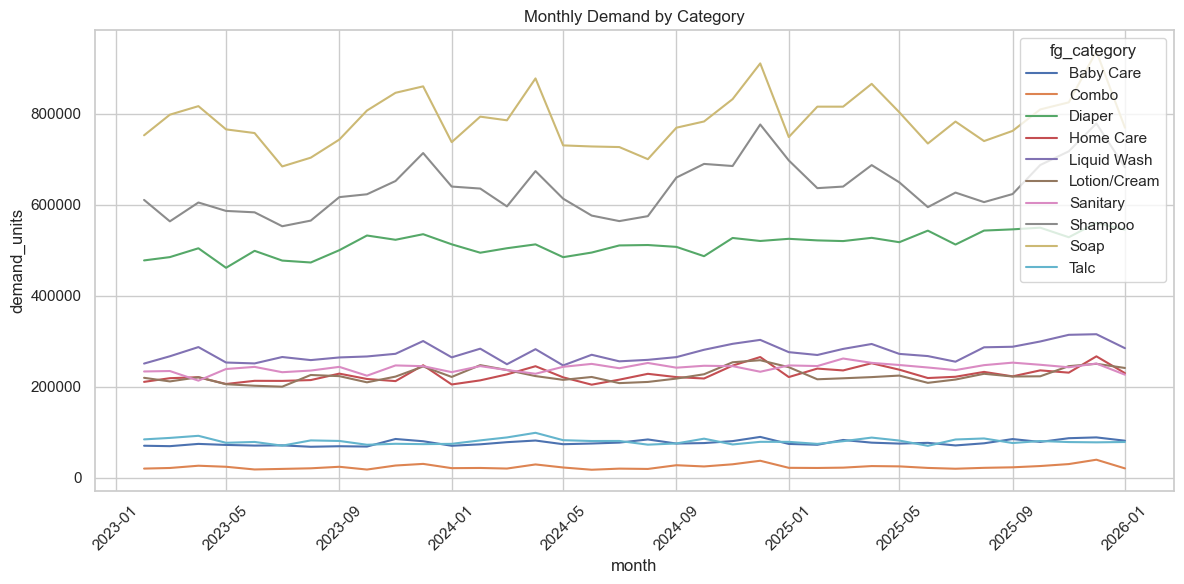

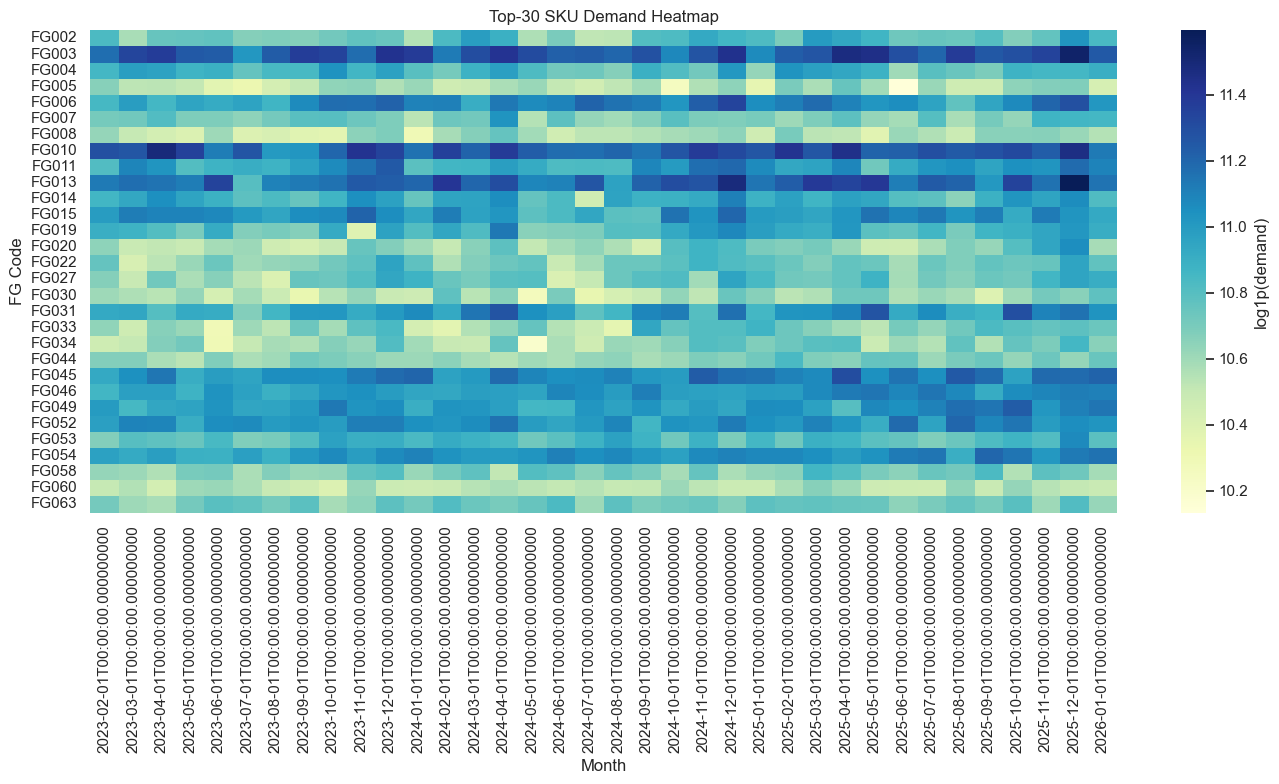

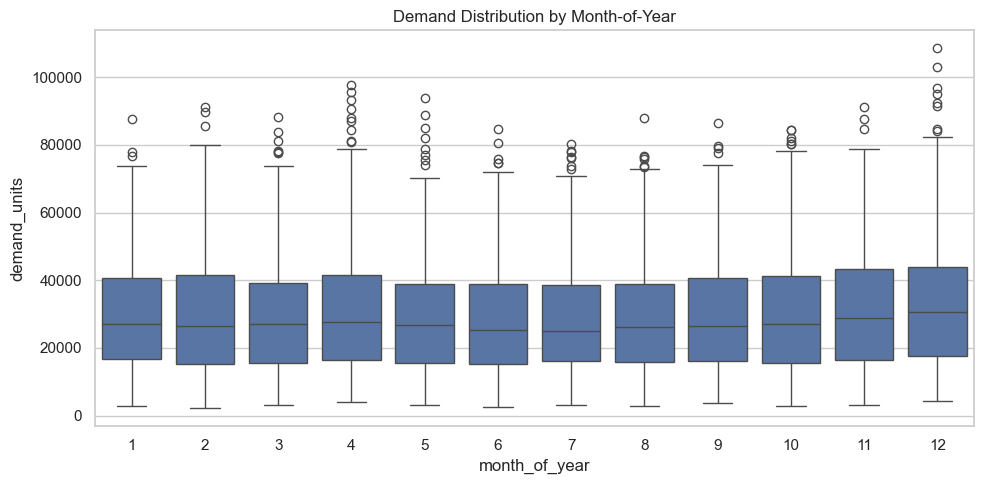

In [56]:
# =========================================
# BLOCK 14 — Demand Visual Diagnostics
# =========================================

# 1) Category-level monthly demand trend.
cat_monthly = clean_df.groupby(["month", "fg_category"], as_index=False)["demand_units"].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=cat_monthly, x="month", y="demand_units", hue="fg_category")
plt.title("Monthly Demand by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2) SKU volatility map: top 30 SKUs by total demand.
ranked_skus = clean_df.groupby("fg_code")["demand_units"].sum().sort_values(ascending=False).head(30).index
pivot = clean_df[clean_df["fg_code"].isin(ranked_skus)].pivot_table(index="fg_code", columns="month", values="demand_units", aggfunc="sum")

plt.figure(figsize=(14, 8))
sns.heatmap(np.log1p(pivot), cmap="YlGnBu", cbar_kws={"label": "log1p(demand)"})
plt.title("Top-30 SKU Demand Heatmap")
plt.xlabel("Month")
plt.ylabel("FG Code")
plt.tight_layout()
plt.show()

# 3) Seasonal profile (boxplot by month-of-year).
tmp = clean_df.copy()
tmp["month_of_year"] = tmp["month"].dt.month

plt.figure(figsize=(10, 5))
sns.boxplot(data=tmp, x="month_of_year", y="demand_units")
plt.title("Demand Distribution by Month-of-Year")
plt.tight_layout()
plt.show()


In [57]:
# =========================================
# BLOCK 15 — Robust Outlier Detection (Per SKU)
# =========================================

# We keep original demand and create a cleaned target:
# demand_units_clean. Outliers are flagged rather than dropped.

def flag_and_clean(group, z_thresh=3.5, iqr_k=2.0):
    g = group.sort_values("month").copy()
    y = g["demand_units"].to_numpy(dtype=float)

    med = np.median(y)
    mad = median_abs_deviation(y, scale="normal")

    if mad == 0:
        robust_z = np.zeros_like(y)
    else:
        robust_z = (y - med) / mad

    q1, q3 = np.quantile(y, [0.25, 0.75])
    iqr = q3 - q1
    lo = max(0.0, q1 - iqr_k * iqr)
    hi = q3 + iqr_k * iqr

    z_flag = np.abs(robust_z) > z_thresh
    iqr_flag = (y < lo) | (y > hi)
    flag = z_flag | iqr_flag

    y_clean = y.copy()
    y_clean[flag] = np.clip(y_clean[flag], lo, hi)

    g["robust_z"] = robust_z
    g["is_outlier"] = flag.astype(int)
    g["demand_units_clean"] = y_clean
    g["outlier_low"] = lo
    g["outlier_high"] = hi
    return g

cleaned_df = pd.concat(
    [flag_and_clean(g) for _, g in clean_df.groupby("fg_code", sort=False)],
    ignore_index=True
)

outlier_rate = cleaned_df["is_outlier"].mean()
outlier_sku_count = cleaned_df.groupby("fg_code")["is_outlier"].sum().gt(0).sum()

print("Flagged outlier rows:", int(cleaned_df["is_outlier"].sum()))
print("Outlier rate (% rows):", round(100 * outlier_rate, 2))
print("SKUs with >=1 outlier:", int(outlier_sku_count), "of", cleaned_df["fg_code"].nunique())

# Compare totals before/after cleaning.
compare_totals = pd.DataFrame({
    "raw_total": cleaned_df.groupby("fg_code")["demand_units"].sum(),
    "clean_total": cleaned_df.groupby("fg_code")["demand_units_clean"].sum(),
})
compare_totals["pct_change"] = (compare_totals["clean_total"] - compare_totals["raw_total"]) / compare_totals["raw_total"].replace(0, np.nan)

print("\nPer-SKU total demand change after capping (%):")
print((100 * compare_totals["pct_change"]).describe(percentiles=[0.05, 0.5, 0.95]).round(3))


Flagged outlier rows: 23
Outlier rate (% rows): 0.62
SKUs with >=1 outlier: 17 of 103

Per-SKU total demand change after capping (%):
count    103.000
mean      -0.027
std        0.200
min       -1.912
5%        -0.128
50%        0.000
95%        0.000
max        0.332
Name: pct_change, dtype: float64


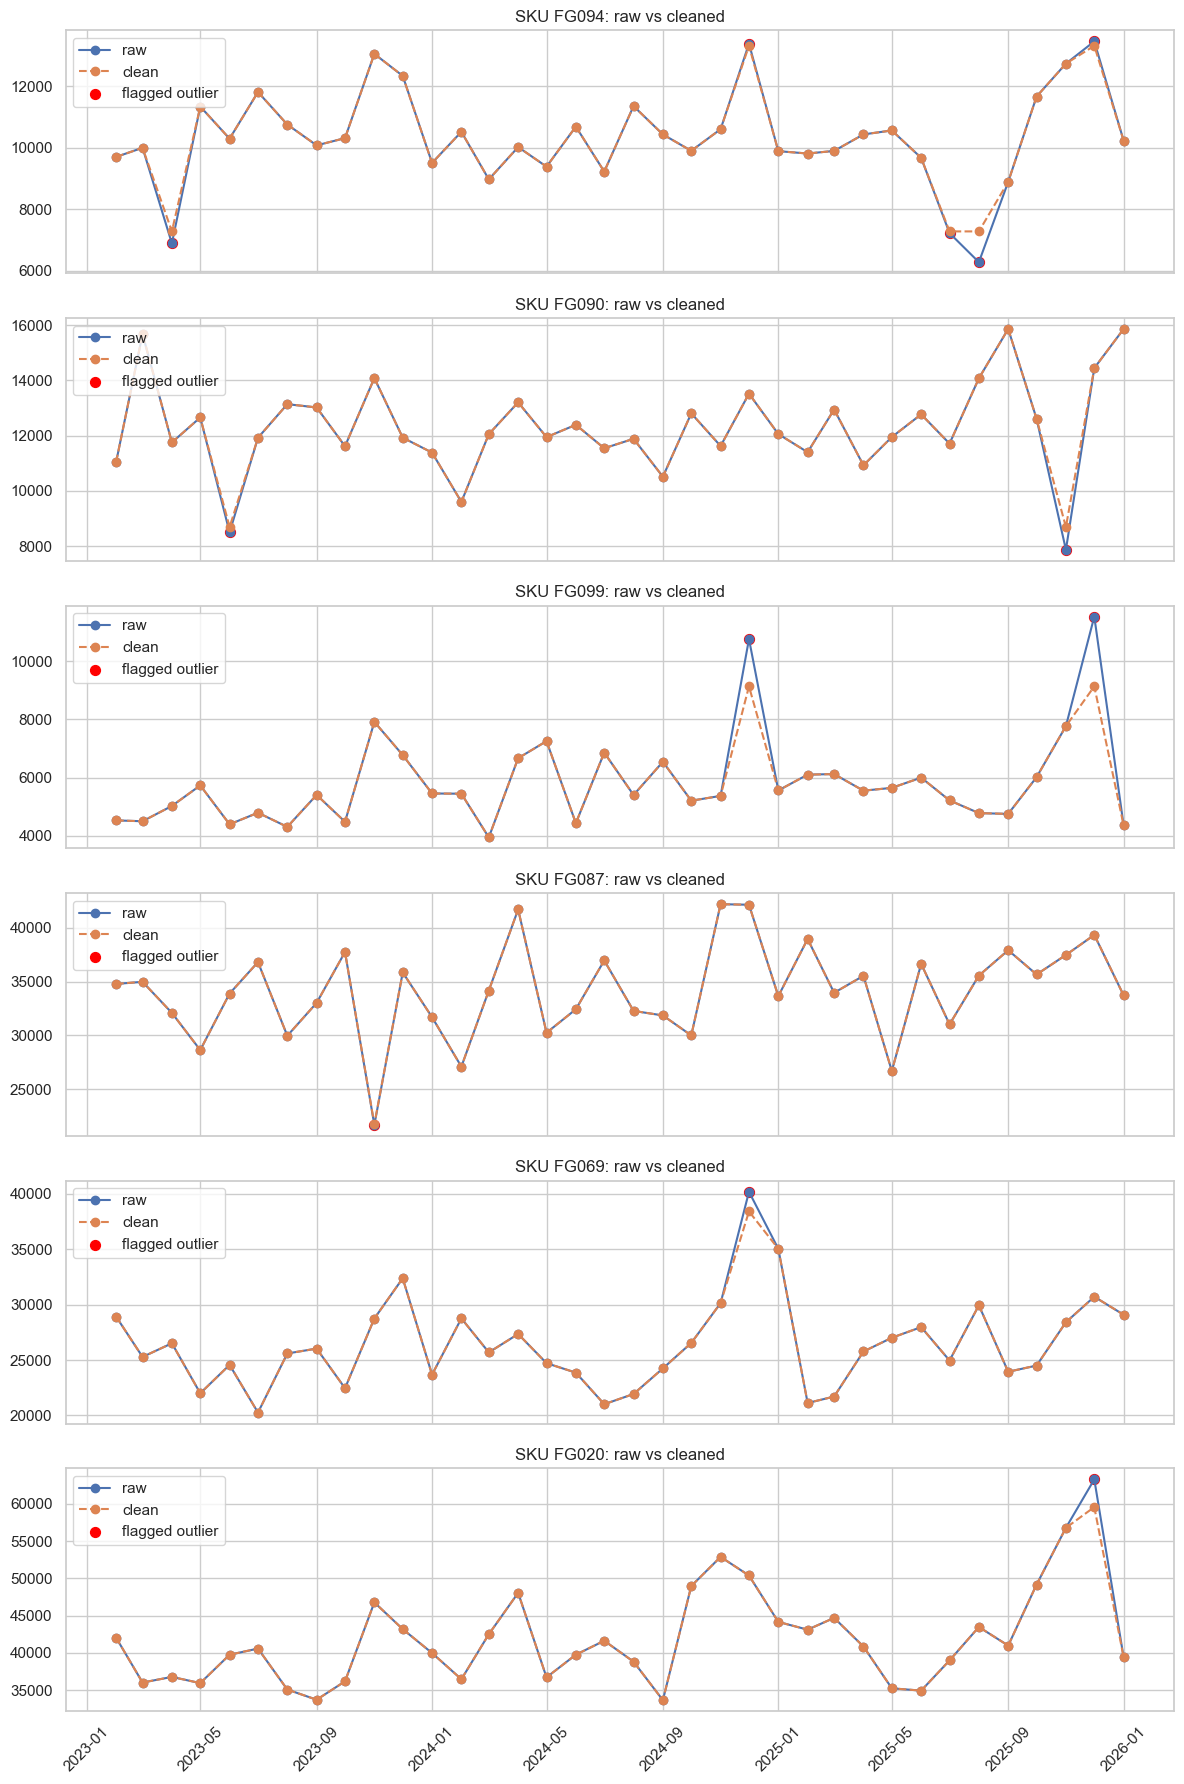

In [58]:
# =========================================
# BLOCK 16 — Before/After Outlier Cleaning Plots
# =========================================

# Plot SKUs with highest outlier counts.
outlier_rank = (
    cleaned_df.groupby("fg_code")["is_outlier"]
    .sum()
    .sort_values(ascending=False)
)
top_problem_skus = outlier_rank[outlier_rank > 0].head(6).index.tolist()

if len(top_problem_skus) == 0:
    print("No outliers were flagged with current thresholds.")
else:
    n = len(top_problem_skus)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, sku in zip(axes, top_problem_skus):
        d = cleaned_df[cleaned_df["fg_code"] == sku].sort_values("month")
        ax.plot(d["month"], d["demand_units"], marker="o", label="raw")
        ax.plot(d["month"], d["demand_units_clean"], marker="o", label="clean", linestyle="--")

        flagged = d[d["is_outlier"] == 1]
        ax.scatter(flagged["month"], flagged["demand_units"], color="red", s=50, label="flagged outlier")

        ax.set_title(f"SKU {sku}: raw vs cleaned")
        ax.legend(loc="upper left")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


STL forecastability statistics:
       trend_strength  season_strength
count         103.000          103.000
mean            0.172            0.555
std             0.147            0.179
min             0.000            0.031
25%             0.049            0.453
50%             0.160            0.589
75%             0.256            0.666
max             0.590            0.885


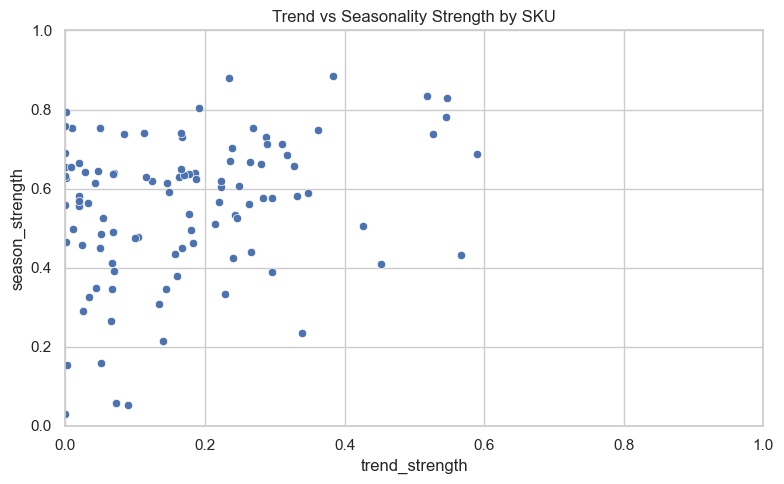

In [59]:
# =========================================
# BLOCK 17 — Trend/Seasonality Strength (Forecastability)
# =========================================

# STL decomposition diagnostics for each SKU.
# Requires at least 24 monthly points; we have 36, so this is valid.

def stl_strength(series, period=12):
    y = series.astype(float)
    if len(y) < period * 2:
        return pd.Series({"trend_strength": np.nan, "season_strength": np.nan})

    try:
        stl = STL(y, period=period, robust=True).fit()
        resid_var = np.var(stl.resid)

        trend_strength = max(0, 1 - resid_var / np.var(stl.trend + stl.resid)) if np.var(stl.trend + stl.resid) > 0 else 0
        season_strength = max(0, 1 - resid_var / np.var(stl.seasonal + stl.resid)) if np.var(stl.seasonal + stl.resid) > 0 else 0
        return pd.Series({"trend_strength": float(trend_strength), "season_strength": float(season_strength)})
    except Exception:
        return pd.Series({"trend_strength": np.nan, "season_strength": np.nan})

stl_stats = (
    cleaned_df.groupby("fg_code", sort=False)
    .apply(lambda g: stl_strength(g["demand_units_clean"].values, period=12))
    .reset_index()
)

print("STL forecastability statistics:")
print(stl_stats[["trend_strength", "season_strength"]].describe().round(3))

plt.figure(figsize=(8, 5))
sns.scatterplot(data=stl_stats, x="trend_strength", y="season_strength")
plt.title("Trend vs Seasonality Strength by SKU")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [60]:
# =========================================
# BLOCK 18 — Forecast Validation Design (WMS-safe)
# =========================================

# Suggested horizon for monthly planning.
forecast_horizon = 3  # months ahead; tune to your replenishment cycle

# Rolling-origin split proposal.
all_months_sorted = np.sort(cleaned_df["month"].unique())

# Keep last 6 months for validation+test, split as 3+3.
if len(all_months_sorted) < 18:
    raise ValueError("Not enough history for robust backtesting.")

train_end = all_months_sorted[-7]
val_end = all_months_sorted[-4]

def assign_split(m):
    if m <= train_end:
        return "train"
    if m <= val_end:
        return "validation"
    return "test"

cleaned_df["split"] = cleaned_df["month"].map(assign_split)

print("Split month ranges:")
print("train      <=", pd.to_datetime(train_end).date())
print("validation <=", pd.to_datetime(val_end).date())
print("test       >", pd.to_datetime(val_end).date())

print("\nRows by split:")
print(cleaned_df["split"].value_counts())

# Metrics to report for WMS forecasting.
print("\nRecommended scorecard metrics:")
print("1) WAPE (volume weighted)")
print("2) MASE (scale-free")
print("3) Bias (ME / MPE)")
print("4) Service-level proxy: under-forecast rate")


Split month ranges:
train      <= 2025-07-01
validation <= 2025-10-01
test       > 2025-10-01

Rows by split:
split
train         3090
validation     309
test           309
Name: count, dtype: int64

Recommended scorecard metrics:
1) WAPE (volume weighted)
2) MASE (scale-free
3) Bias (ME / MPE)
4) Service-level proxy: under-forecast rate


In [61]:
# =========================================
# BLOCK 19 — Feature Engineering Blueprint (for XGB/CatBoost/TFT)
# =========================================

model_df = cleaned_df.copy()

# Time features.
model_df["year"] = model_df["month"].dt.year
model_df["month_num"] = model_df["month"].dt.month
model_df["quarter"] = model_df["month"].dt.quarter
model_df["is_year_end"] = (model_df["month"].dt.month == 12).astype(int)

# Cyclical encoding for month-of-year.
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month_num"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month_num"] / 12)

# Lag and rolling features (per SKU).
for lag in [1, 2, 3, 6, 12]:
    model_df[f"lag_{lag}"] = model_df.groupby("fg_code")["demand_units_clean"].shift(lag)

for win in [3, 6, 12]:
    model_df[f"roll_mean_{win}"] = (
        model_df.groupby("fg_code")["demand_units_clean"]
        .shift(1)
        .rolling(win)
        .mean()
        .reset_index(level=0, drop=True)
    )
    model_df[f"roll_std_{win}"] = (
        model_df.groupby("fg_code")["demand_units_clean"]
        .shift(1)
        .rolling(win)
        .std()
        .reset_index(level=0, drop=True)
    )

# Cold-start warning caused by lagging.
na_ratio = model_df.isna().mean().sort_values(ascending=False)
print("Top missing ratios after lag features:")
print((100 * na_ratio.head(10)).round(2).astype(str) + "%")

# Columns expected from WMS/ERP for stronger forecasts.
recommended_external_features = [
    "on_hand_inventory",
    "stockout_days",
    "promotion_flag",
    "price_or_discount",
    "lead_time_days",
    "supplier_otif",
    "inbound_po_qty",
    "open_sales_orders",
    "returns_qty",
    "holiday_flag"
]

print("\nExternal WMS/ERP features to add if available:")
for i, f in enumerate(recommended_external_features, start=1):
    print(f"{i}. {f}")


Top missing ratios after lag features:
roll_std_12     33.33%
roll_mean_12    33.33%
lag_12          33.33%
roll_std_6      16.67%
roll_mean_6     16.67%
lag_6           16.67%
roll_std_3       8.33%
roll_mean_3      8.33%
lag_3            8.33%
lag_2            5.56%
dtype: object

External WMS/ERP features to add if available:
1. on_hand_inventory
2. stockout_days
3. promotion_flag
4. price_or_discount
5. lead_time_days
6. supplier_otif
7. inbound_po_qty
8. open_sales_orders
9. returns_qty
10. holiday_flag


In [62]:
# =========================================
# BLOCK 20 — Persist Cleaned and Modeling Tables
# =========================================

output_dir = "/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms"

clean_path = f"{output_dir}/hemas_monthly_cleaned_with_outliers.csv"
model_path = f"{output_dir}/hemas_monthly_model_features.csv"

cleaned_df.to_csv(clean_path, index=False)
model_df.to_csv(model_path, index=False)

print("Saved:")
print(clean_path)
print(model_path)


Saved:
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_monthly_cleaned_with_outliers.csv
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_monthly_model_features.csv


In [63]:
# =========================================
# BLOCK 21 — Go/No-Go Readiness Checklist
# =========================================

# This cell classifies readiness for:
# 1) Baseline-ready: enough quality to train/evaluate core forecasting models.
# 2) Production-ready: includes business drivers needed for robust WMS decisions.

import pandas as pd

if "model_df" not in globals():
    model_df = cleaned_df.copy() if "cleaned_df" in globals() else clean_df.copy()

work_df = cleaned_df.copy() if "cleaned_df" in globals() else clean_df.copy()

required_core_cols = ["month", "fg_code", "fg_name", "fg_category", "demand_units"]
core_cols_present = all(c in work_df.columns for c in required_core_cols)

null_count = int(work_df[required_core_cols].isna().sum().sum()) if core_cols_present else -1
neg_count = int((work_df["demand_units"] < 0).sum()) if "demand_units" in work_df.columns else -1
dupe_key = int(work_df.duplicated(["fg_code", "month"]).sum()) if all(c in work_df.columns for c in ["fg_code", "month"]) else -1

sku_n = int(work_df["fg_code"].nunique()) if "fg_code" in work_df.columns else 0
month_n = int(work_df["month"].nunique()) if "month" in work_df.columns else 0

obs_per_sku = work_df.groupby("fg_code").size() if "fg_code" in work_df.columns else pd.Series(dtype=float)
balanced_panel = bool(obs_per_sku.nunique() == 1) if len(obs_per_sku) else False

outlier_col_ok = "is_outlier" in work_df.columns
clean_target_ok = "demand_units_clean" in work_df.columns

# WMS production-driving fields expected for operational forecasting.
wms_feature_candidates = [
    "on_hand_inventory",
    "stockout_days",
    "promotion_flag",
    "price_or_discount",
    "lead_time_days",
    "supplier_otif",
    "inbound_po_qty",
    "open_sales_orders",
    "returns_qty",
    "holiday_flag",
]
present_wms_features = [c for c in wms_feature_candidates if c in model_df.columns]

checks = [
    ("Core columns present", core_cols_present),
    ("No nulls in core columns", null_count == 0),
    ("No negative demand", neg_count == 0),
    ("No duplicate (fg_code, month)", dupe_key == 0),
    ("At least 24 months history", month_n >= 24),
    ("At least 50 SKUs", sku_n >= 50),
    ("Balanced panel by SKU", balanced_panel),
    ("Outlier flags available", outlier_col_ok),
    ("Clean target available", clean_target_ok),
]

baseline_required = [
    "Core columns present",
    "No nulls in core columns",
    "No negative demand",
    "No duplicate (fg_code, month)",
    "At least 24 months history",
    "Balanced panel by SKU",
]

baseline_ready = all(v for k, v in checks if k in baseline_required)

# Production-ready requires baseline + at least 4 WMS driver features.
production_ready = baseline_ready and (len(present_wms_features) >= 4)

status_rows = []
for name, passed in checks:
    status_rows.append({"check": name, "status": "PASS" if passed else "FAIL"})

status_df = pd.DataFrame(status_rows)
print(status_df.to_string(index=False))

print("\nSummary")
print("Baseline-ready:", "YES" if baseline_ready else "NO")
print("Production-ready:", "YES" if production_ready else "NO")

if not production_ready:
    missing_needed = max(0, 4 - len(present_wms_features))
    missing_pool = [c for c in wms_feature_candidates if c not in present_wms_features]
    print("\nProduction gap analysis")
    print("WMS driver features present:", len(present_wms_features), present_wms_features)
    print("Additional WMS drivers needed (minimum):", missing_needed)
    print("Suggested next additions:", missing_pool[:missing_needed if missing_needed > 0 else 3])

# Machine-readable readiness object for later cells.
readiness_report = {
    "baseline_ready": baseline_ready,
    "production_ready": production_ready,
    "checks": dict(checks),
    "present_wms_features": present_wms_features,
    "required_wms_feature_min_for_prod": 4,
}


                        check status
         Core columns present   PASS
     No nulls in core columns   PASS
           No negative demand   PASS
No duplicate (fg_code, month)   PASS
   At least 24 months history   PASS
             At least 50 SKUs   PASS
        Balanced panel by SKU   PASS
      Outlier flags available   PASS
       Clean target available   PASS

Summary
Baseline-ready: YES
Production-ready: NO

Production gap analysis
WMS driver features present: 0 []
Additional WMS drivers needed (minimum): 4
Suggested next additions: ['on_hand_inventory', 'stockout_days', 'promotion_flag', 'price_or_discount']


In [ ]:
# =========================================
# BLOCK 22 — Original vs Augmented Validation
# =========================================

# Purpose:
# 1) Validate augmented WMS fields are in realistic ranges.
# 2) Compare key statistical relationships with the original demand panel.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ORIGINAL_PATH = "/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_synthetic_forecasting_dataset_monthly_36m.xlsx"
AUG_PATH = "/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_monthly_augmented_wms_features.xlsx"

orig = pd.read_excel(ORIGINAL_PATH, sheet_name="FG_Demand_Long")
aug = pd.read_excel(AUG_PATH, sheet_name="FG_Demand_Long_Augmented")

orig["month"] = pd.to_datetime(orig["month"])
aug["month"] = pd.to_datetime(aug["month"])

# Join to ensure row-level alignment check on keys.
check = aug.merge(
    orig[["fg_code", "month", "demand_units"]],
    on=["fg_code", "month"],
    how="left",
    suffixes=("_aug", "_orig")
)

print("Shape original:", orig.shape)
print("Shape augmented:", aug.shape)
print("Key duplicates in augmented:", int(aug.duplicated(["fg_code", "month"]).sum()))
print("Demand mismatch rows (aug vs original):", int((check["demand_units_aug"] != check["demand_units_orig"]).sum()))

# Range checks for synthetic WMS features.
range_checks = {
    "on_hand_inventory_non_negative": (aug["on_hand_inventory"] >= 0).all(),
    "stockout_days_0_to_31": aug["stockout_days"].between(0, 31).all(),
    "promotion_flag_binary": aug["promotion_flag"].isin([0, 1]).all(),
    "price_or_discount_0_to_0.5": aug["price_or_discount"].between(0, 0.5).all(),
    "lead_time_days_1_to_120": aug["lead_time_days"].between(1, 120).all(),
    "supplier_otif_0_to_1": aug["supplier_otif"].between(0, 1).all(),
    "inbound_po_qty_non_negative": (aug["inbound_po_qty"] >= 0).all(),
    "open_sales_orders_non_negative": (aug["open_sales_orders"] >= 0).all(),
    "returns_qty_non_negative": (aug["returns_qty"] >= 0).all(),
    "holiday_flag_binary": aug["holiday_flag"].isin([0, 1]).all(),
}

print("\nRange checks:")
for k, v in range_checks.items():
    print(f"{k}: {'PASS' if bool(v) else 'FAIL'}")

print("\nAugmented feature summary:")
summary_cols = [
    "on_hand_inventory", "stockout_days", "promotion_flag", "price_or_discount",
    "lead_time_days", "supplier_otif", "inbound_po_qty", "open_sales_orders",
    "returns_qty", "holiday_flag"
]
print(aug[summary_cols].describe().round(3))

# Correlation sanity checks against demand.
corr_cols = ["demand_units"] + summary_cols
corr = aug[corr_cols].corr(numeric_only=True)["demand_units"].sort_values(ascending=False)
print("\nCorrelation with demand_units:")
print(corr.round(3))

# Visual checks.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(aug["lead_time_days"], bins=25, kde=True, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Lead Time Distribution")

sns.histplot(aug["supplier_otif"], bins=25, kde=True, ax=axes[0, 1], color="#2ca02c")
axes[0, 1].set_title("Supplier OTIF Distribution")

sns.boxplot(data=aug, x="promotion_flag", y="demand_units", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Demand by Promotion Flag")

sample_n = min(1500, len(aug))
sns.scatterplot(
    data=aug.sample(sample_n, random_state=42),
    x="on_hand_inventory",
    y="demand_units",
    alpha=0.5,
    ax=axes[1, 1],
    color="#ff7f0e",
)
axes[1, 1].set_title("On-hand vs Demand (sample)")

plt.tight_layout()
plt.show()

# Quick verdict flags.
baseline_ready = all(range_checks.values()) and int((check["demand_units_aug"] != check["demand_units_orig"]).sum()) == 0
print("\nValidation verdict:")
print("Augmented dataset structurally consistent:", "YES" if baseline_ready else "NO")
